# Heterogeneity, where does the treatment effect concentrate

If the average D30 effect of getting an answer within 24 hours is +7.7 pp, the natural follow-up is whether that average hides meaningful variation across user types. The question I want to answer in this notebook is: which new contributors does the answer help most, and which is the effect smallest for?

Four cuts. By body-length quartile (a proxy for effort). By has-code-block (programming-question vs not). By cohort year (over time). By tag language (python users vs javascript vs other), pulled from the first_tag column in cohort.parquet.

For each cut, I'm running the same controlled OLS as in notebook 02 (linear probability model with covariates) on the subset, and reading off the treatment coefficient. The differences across subsets are the heterogeneous effects.

In [1]:
import warnings

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf

import db_dtypes  # noqa: F401

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

DATA_DIR = '../data/processed'

df = pq.read_table(f'{DATA_DIR}/master.parquet').to_pandas()
df['log_body_length'] = np.log(df['body_length'].clip(lower=1))
df['cohort_year'] = pd.to_datetime(df['cohort_month']).dt.year

for col in ['active_d30', 'got_answer_within_24h', 'has_code_block', 'has_link', 'has_image',
             'is_weekend', 'title_length', 'num_tags', 'hour_of_day_utc', 'day_of_week']:
    df[col] = df[col].astype(float)

# Join first_tag from cohort.parquet for the language cut
cohort = pq.read_table(f'{DATA_DIR}/cohort.parquet').to_pandas()
df = df.merge(cohort[['user_id', 'first_tag']], on='user_id', how='left')

print(f'Loaded master.parquet: {len(df):,} rows')
print(f'first_tag null rate (answer-first users, dropped in master already): {df["first_tag"].isna().mean()*100:.1f}%')

Loaded master.parquet: 1,772,119 rows
first_tag null rate (answer-first users, dropped in master already): 0.0%


## 1. Body length quartile

Short-body first questions (under 500 chars) are typically vague help requests with no detail. Long-body first questions are usually well-described problems with code, expected vs actual behavior, and so on. The treatment effect might be smaller for short-body posters (their questions don't deserve an answer and they wouldn't have retained anyway) and larger for long-body posters (good question, got a quality answer, felt rewarded).

In [2]:
covariates = (
    'log_body_length + title_length + has_code_block + has_link + has_image '
    '+ num_tags + C(day_of_week) + C(hour_of_day_utc) + C(cohort_year)'
)

def het_ols(sub, label, n_total):
    if len(sub) < 5000:
        return None
    try:
        model = smf.ols(f'active_d30 ~ got_answer_within_24h + {covariates}', data=sub).fit(cov_type='HC3')
        coef = model.params['got_answer_within_24h']
        se = model.bse['got_answer_within_24h']
        ci = model.conf_int().loc['got_answer_within_24h']
        return {'label': label, 'n': len(sub), 'share': len(sub) / n_total,
                'estimate_pp': coef * 100, 'se_pp': se * 100,
                'ci_low': ci.iloc[0] * 100, 'ci_high': ci.iloc[1] * 100}
    except Exception as e:
        print(f'Failed for {label}: {e}')
        return None

df['body_quartile'] = pd.qcut(df['body_length'], 4, labels=['Q1 short', 'Q2', 'Q3', 'Q4 long'])
rows = []
for q in ['Q1 short', 'Q2', 'Q3', 'Q4 long']:
    sub = df[df['body_quartile'] == q]
    r = het_ols(sub, q, len(df))
    if r:
        rows.append(r)
body_table = pd.DataFrame(rows)

print('D30 effect by body-length quartile:')
print()
print(body_table.to_string(index=False, float_format=lambda x: f'{x:+.2f}' if isinstance(x, float) else str(x)))

D30 effect by body-length quartile:

   label      n  share  estimate_pp  se_pp  ci_low  ci_high
Q1 short 443258  +0.25        +6.93  +0.12   +6.69    +7.17
      Q2 443432  +0.25        +7.61  +0.13   +7.35    +7.87
      Q3 442614  +0.25        +7.91  +0.13   +7.65    +8.17
 Q4 long 442815  +0.25        +8.33  +0.14   +8.07    +8.60


## 2. Has-code-block split

Code-block first questions are the canonical programming question. No-code-block first questions are concept questions, screenshots, or vague help requests. Different effect plausibly.

In [3]:
rows = []
for flag in [0, 1]:
    sub = df[df['has_code_block'] == flag]
    label = 'no code block' if flag == 0 else 'has code block'
    r = het_ols(sub, label, len(df))
    if r:
        rows.append(r)
code_table = pd.DataFrame(rows)

print('D30 effect by code-block presence:')
print()
print(code_table.to_string(index=False, float_format=lambda x: f'{x:+.2f}' if isinstance(x, float) else str(x)))

D30 effect by code-block presence:

         label       n  share  estimate_pp  se_pp  ci_low  ci_high
 no code block  383387  +0.22        +6.54  +0.13   +6.29    +6.78
has code block 1388732  +0.78        +8.05  +0.08   +7.90    +8.20


## 3. Tag language

The first_tag column in cohort.parquet is the full pipe-separated tag string (this is a known wart from sql-01, the parsing didn't split properly). I'm extracting the first token from the pipe-separated list as the primary language, then bucketing into the most common ones plus an 'other' bucket.

Languages I expect to see most of: python, javascript, java, c#, php, html, c++, sql, r, typescript.

In [4]:
def first_token(s):
    if pd.isna(s):
        return None
    parts = str(s).split('|')
    return parts[0] if parts else None

df['primary_tag'] = df['first_tag'].apply(first_token)
tag_counts = df['primary_tag'].value_counts().head(15)
print('Top 15 primary tags:')
print(tag_counts)

Top 15 primary tags:
primary_tag
python        297001
javascript    184215
java          130838
c#             80782
php            65167
c++            55116
r              54060
android        48370
sql            35432
html           34547
c              32144
excel          28717
reactjs        25593
node.js        24999
python-3.x     23756
Name: count, dtype: int64


In [5]:
top_tags = tag_counts.head(10).index.tolist()
df['tag_bucket'] = df['primary_tag'].where(df['primary_tag'].isin(top_tags), 'other')

rows = []
for tag in top_tags + ['other']:
    sub = df[df['tag_bucket'] == tag]
    r = het_ols(sub, tag, len(df))
    if r:
        rows.append(r)
tag_table = pd.DataFrame(rows).sort_values('estimate_pp', ascending=False).reset_index(drop=True)

print('D30 effect by primary tag:')
print()
print(tag_table.to_string(index=False, float_format=lambda x: f'{x:+.2f}' if isinstance(x, float) else str(x)))

D30 effect by primary tag:

     label      n  share  estimate_pp  se_pp  ci_low  ci_high
         r  54060  +0.03        +9.96  +0.37   +9.23   +10.69
   android  48370  +0.03        +9.86  +0.40   +9.07   +10.65
javascript 184215  +0.10        +9.04  +0.22   +8.61    +9.47
    python 297001  +0.17        +8.39  +0.17   +8.06    +8.72
     other 786591  +0.44        +7.71  +0.10   +7.52    +7.90
       php  65167  +0.04        +7.46  +0.36   +6.76    +8.16
      html  34547  +0.02        +6.59  +0.52   +5.56    +7.61
       sql  35432  +0.02        +6.26  +0.56   +5.17    +7.34
      java 130838  +0.07        +6.18  +0.25   +5.69    +6.68
        c#  80782  +0.05        +5.24  +0.32   +4.61    +5.88
       c++  55116  +0.03        +3.66  +0.40   +2.88    +4.44


## 4. Cohort year, controlled

Same as notebook 03's subsample analysis but reproduced here for the heterogeneity story. I'm interested in whether the answer-retention link weakened over time, possibly as alternative help sources (ChatGPT-style models from late 2022, Copilot from mid-2021) entered the picture.

In [6]:
covariates_nocohort = (
    'log_body_length + title_length + has_code_block + has_link + has_image '
    '+ num_tags + C(day_of_week) + C(hour_of_day_utc)'
)

rows = []
for year in sorted(df['cohort_year'].unique()):
    sub = df[df['cohort_year'] == year]
    if len(sub) < 5000:
        continue
    model = smf.ols(f'active_d30 ~ got_answer_within_24h + {covariates_nocohort}', data=sub).fit(cov_type='HC3')
    coef = model.params['got_answer_within_24h']
    se = model.bse['got_answer_within_24h']
    ci = model.conf_int().loc['got_answer_within_24h']
    rows.append({'label': str(int(year)), 'n': len(sub), 'share': len(sub)/len(df),
                 'estimate_pp': coef * 100, 'se_pp': se * 100,
                 'ci_low': ci.iloc[0] * 100, 'ci_high': ci.iloc[1] * 100})
year_table = pd.DataFrame(rows)

print('D30 effect by cohort year (controlled, no cohort_year FE):')
print()
print(year_table.to_string(index=False, float_format=lambda x: f'{x:+.2f}' if isinstance(x, float) else str(x)))

D30 effect by cohort year (controlled, no cohort_year FE):

label      n  share  estimate_pp  se_pp  ci_low  ci_high
 2018 356094  +0.20        +5.96  +0.15   +5.66    +6.26
 2019 357957  +0.20        +6.65  +0.15   +6.36    +6.95
 2020 391034  +0.22        +7.06  +0.14   +6.78    +7.34
 2021 362195  +0.20        +7.99  +0.14   +7.72    +8.27
 2022 304839  +0.17       +11.03  +0.15  +10.73   +11.32


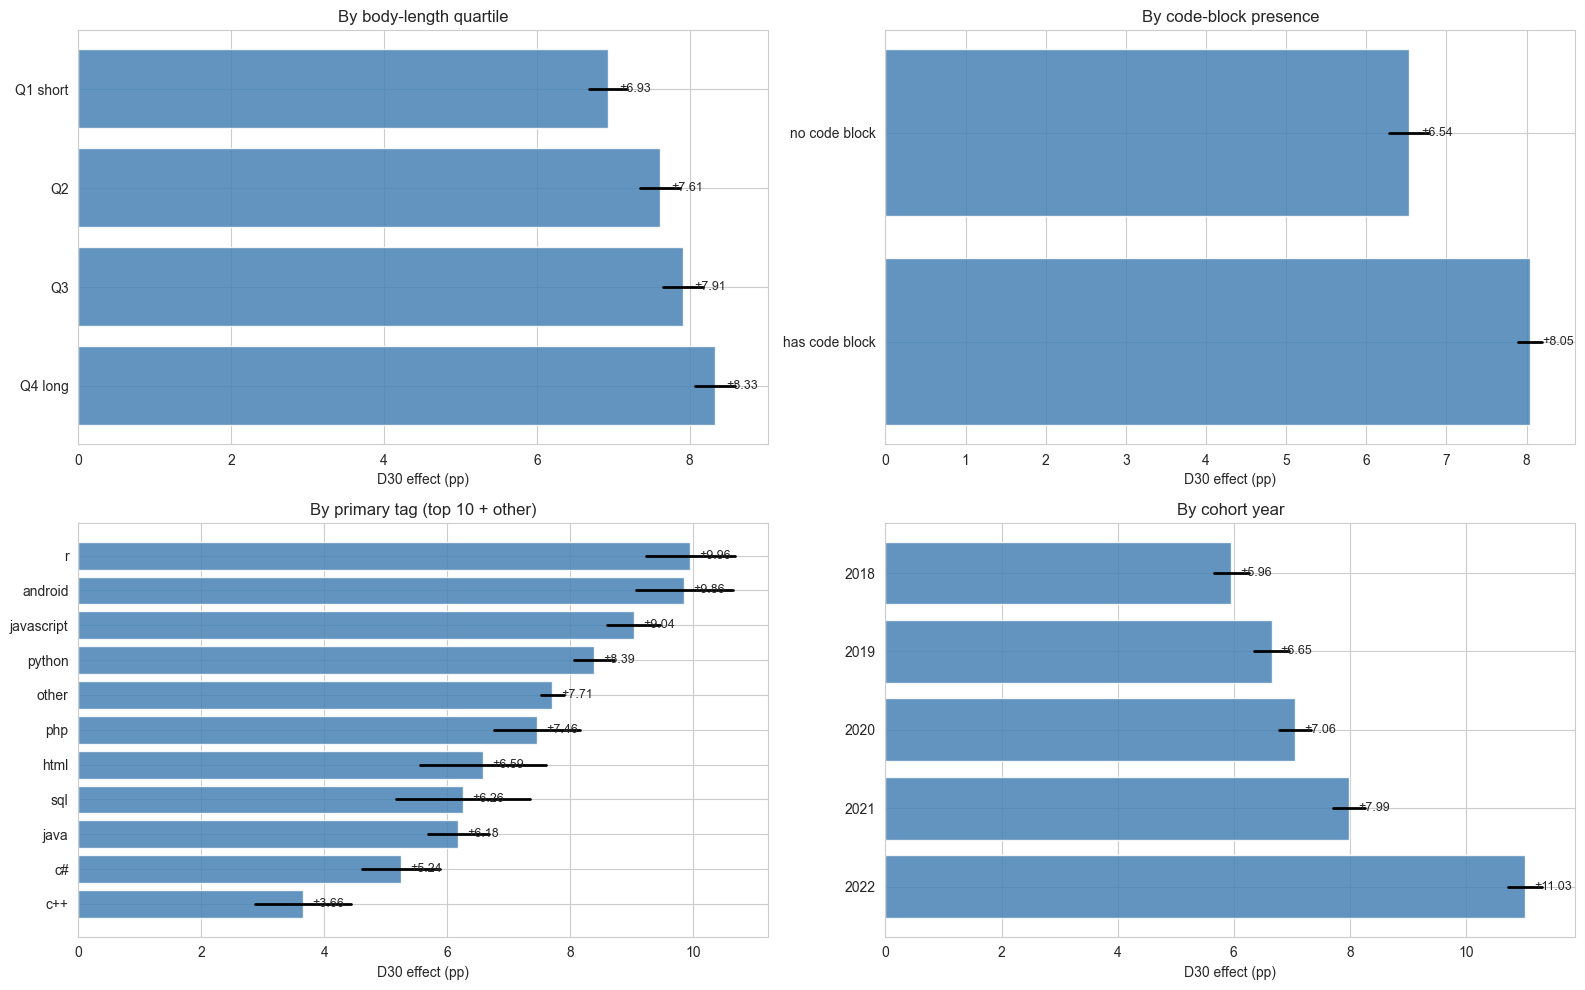

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

def het_chart(ax, table, title):
    y = np.arange(len(table))
    ax.barh(y, table['estimate_pp'], color='steelblue', alpha=0.85)
    for i, row in table.iterrows():
        ax.plot([row['ci_low'], row['ci_high']], [i, i], 'k-', lw=2)
        ax.text(row['estimate_pp'] + 0.15, i, f"{row['estimate_pp']:+.2f}", va='center', fontsize=9)
    ax.set_yticks(y); ax.set_yticklabels(table['label'])
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title(title); ax.set_xlabel('D30 effect (pp)')
    ax.invert_yaxis()

het_chart(axes[0], body_table, 'By body-length quartile')
het_chart(axes[1], code_table, 'By code-block presence')
het_chart(axes[2], tag_table, 'By primary tag (top 10 + other)')
het_chart(axes[3], year_table, 'By cohort year')

plt.tight_layout()
plt.show()

## 5. Save and summarize

In [8]:
body_table['kind'] = 'body_quartile'
code_table['kind'] = 'code_block'
tag_table['kind'] = 'tag'
year_table['kind'] = 'year'

cols = ['kind', 'label', 'n', 'share', 'estimate_pp', 'se_pp', 'ci_low', 'ci_high']
all_het = pd.concat([body_table[cols], code_table[cols], tag_table[cols], year_table[cols]], ignore_index=True)

out_path = f'{DATA_DIR}/heterogeneity.parquet'
all_het.to_parquet(out_path, index=False)
print(f'Saved: {out_path}')
print()
print(all_het.to_string(index=False, float_format=lambda x: f'{x:+.2f}' if isinstance(x, float) else str(x)))

Saved: ../data/processed/heterogeneity.parquet

         kind          label       n  share  estimate_pp  se_pp  ci_low  ci_high
body_quartile       Q1 short  443258  +0.25        +6.93  +0.12   +6.69    +7.17
body_quartile             Q2  443432  +0.25        +7.61  +0.13   +7.35    +7.87
body_quartile             Q3  442614  +0.25        +7.91  +0.13   +7.65    +8.17
body_quartile        Q4 long  442815  +0.25        +8.33  +0.14   +8.07    +8.60
   code_block  no code block  383387  +0.22        +6.54  +0.13   +6.29    +6.78
   code_block has code block 1388732  +0.78        +8.05  +0.08   +7.90    +8.20
          tag              r   54060  +0.03        +9.96  +0.37   +9.23   +10.69
          tag        android   48370  +0.03        +9.86  +0.40   +9.07   +10.65
          tag     javascript  184215  +0.10        +9.04  +0.22   +8.61    +9.47
          tag         python  297001  +0.17        +8.39  +0.17   +8.06    +8.72
          tag          other  786591  +0.44        +7.71  +0.